# Project 2: food desert community compared to a non-food desert community

### Author:

In [1]:
import pandas as pd

df = pd.read_csv("EEP 153 Project 2 Meal ingredient Prices - Grocery List.csv")
df.head()

import os
os.listdir()

['InaayaHasham.txt',
 'README.md',
 'EEP 153 Project 2 Meal ingredient Prices - Grocery List.csv',
 '.git',
 '.gitignore',
 '.ipynb_checkpoints',
 'Code.ipynb']

In [2]:
df = pd.read_csv("EEP 153 Project 2 Meal ingredient Prices - Grocery List.csv")

In [3]:
df.head()

,Item,Bay Area Price,Central Valley Price,Nutrition Info \n(same for both),Food Group,Unnamed: 5,AVERAGES,Bay Area,Central Valley
0,"Great Value Large White Eggs, 12 count",$1.67,$1.47,Calories per serving = 70\nTotal fat = 5g\nCho...,Dairy,NaN,Average Dairy prices,$2.89,$2.88
1,"Great Value Milk (2%, gallon)",$3.00,$3.13,Calories per serving = 130\nTotal fat = 5g\nCh...,Dairy,NaN,Average Grain/Carbs prices,$2.04,$2.81
2,Great Value Cheddar Sharp Cheese (16 oz),$3.58,$3.58,Calories per serving = 110\nTotal fat = 9g\nCh...,Dairy,NaN,Average Protein Prices,$4.06,$3.88
3,Great Value Plain Yogurt (32 oz),$2.76,$2.76,Calories per serving = 80\nTotal fat = 0g\nCho...,Dairy,NaN,Average Produce Prices,$1.47,$1.47
4,Great Value Unsalted Butter (16 oz),$3.44,$3.44,Calories per serving = 100\nTotal fat = 11g\nC...,Dairy,NaN,Average Seasoning/Condiment Prices,$3.02,$2.80


In [4]:
df.columns

Index(['Item', 'Bay Area Price', 'Central Valley Price',
       'Nutrition Info \n(same for both)', 'Food Group', 'Unnamed: 5',
       'AVERAGES', 'Bay Area', 'Central Valley'],
      dtype='object')

In [6]:
import pandas as pd

# 1) Remove $ and any non-numeric characters (keep digits and decimals), then convert to float
for col in ["Bay Area Price", "Central Valley Price"]:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(r"[^0-9.]", "", regex=True)   # keeps only digits and periods
        .replace("", pd.NA)
        .astype(float)
    )

# sanity check
df[["Bay Area Price", "Central Valley Price"]].head()

,Bay Area Price,Central Valley Price
0,1.67,1.47
1,3.00,3.13
2,3.58,3.58
3,2.76,2.76
4,3.44,3.44


In [7]:
group_avg = df.groupby("Food Group")[["Bay Area Price", "Central Valley Price"]].mean()
group_avg

,Bay Area Price,Central Valley Price
Food Group,,
Dairy,2.890000,2.876000
Grains/Carbs,2.044286,2.001429
Produce,1.338571,1.358571
Protein,2.376000,2.302000
Seasonings/Condiments,1.976923,1.943077


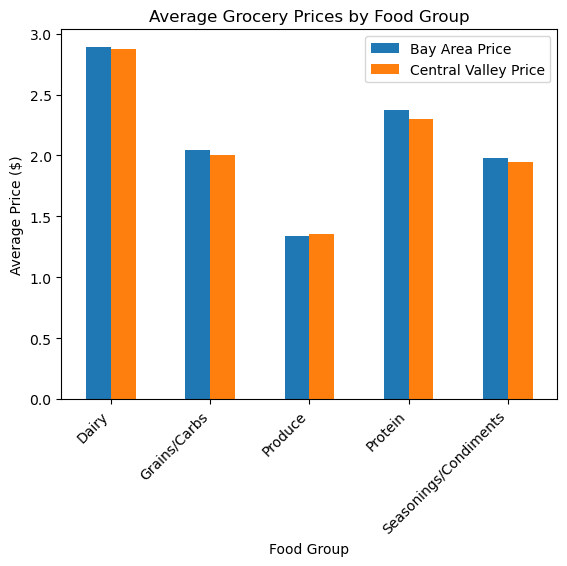

In [8]:
import matplotlib.pyplot as plt

group_avg.plot(kind="bar")
plt.title("Average Grocery Prices by Food Group")
plt.ylabel("Average Price ($)")
plt.xticks(rotation=45, ha="right")
plt.show()